## DS2000 & DS2001 Programming with Data & Practicum

# Homework 9: Bootstrap and Confidence Intervals

### 29 Points

## Due Friday, March 28, 10:00PM

**Reading**: 
* [Chap 12 Comparing Two Samples](https://inferentialthinking.com/chapters/12/Comparing_Two_Samples.html)
* [Chap 13 Estimation](https://www.inferentialthinking.com/chapters/13/Estimation)

Please complete this notebook by filling in the cells provided. Before you begin, execute the following cell to load the provided tests. Each time you start your server, you will need to execute this cell again to load the tests.

For all problems that you must write our explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, please be sure to not re-assign variables throughout the notebook! For example, if you use `max_temperature` in your answer to one question, do not reassign it later on.

**Note: This homework has hidden tests on it. That means even though tests may say 100% passed, it doesn't mean your final grade will be 100%. We will be running more tests for correctness once everyone turns in the homework.**

In [1]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.",
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

import otter
grader = otter.Notebook("hw09.ipynb")

## 1. Thai Restaurants in Oakland

Steph and Adam are trying to see what the best Thai restaurant in Oakland is. They survey 1,500 Oakland residents selected uniformly at random, and ask each resident what Thai restaurant is the best. (*Note: This data is fabricated for the purposes of this homework.*) The choices of Thai restaurants are Lucky House, Imm Thai, Thai Temple, and Thai Basil. After compiling the results, Steph and Adam release the following percentages from their sample:

|Thai Restaurant  | Percentage|
|:------------:|:------------:|
|Lucky House | 8% |
|Imm Thai | 53% |
|Thai Temple | 25% |
|Thai Basil | 14% |

These percentages represent a uniform random sample of the population of Oakland residents. We will attempt to estimate the corresponding *parameters*, or the percentage of the votes that each restaurant will receive from the population (i.e. all Oakland residents). We will use confidence intervals to compute a range of values that reflects the uncertainty of our estimates.

The table `votes` contains the results of Steph and Adam's survey.

In [2]:
# Just run this cell
votes = Table.read_table('votes.csv')
votes

Vote
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House


**Question 1.1. (3 pts)** Complete the function `one_resampled_percentage` below. It should return Imm Thai's **percentage** of votes after taking the original table (`tbl`) and performing one bootstrap sample of it. Reminder that a percentage is between 0 and 100. 

*Note:* `tbl` will always be in the same format as `votes`.

In [3]:
def one_resampled_percentage(tbl):
    sample = tbl.sample().group("Vote")
    def prct(x):
        return (x/sum(sample.column("count")))*100
    return sample.where("Vote", "Imm Thai").apply(prct, "count").item(0)
one_resampled_percentage(votes)

53.46666666666666

In [4]:
grader.check("q1_1")

q1_1 results: All test cases passed!

**Question 1.2. (3 pts)** Complete the `percentages_in_resamples` function such that it simulates and returns an array of 2500 bootstrapped estimates of the percentage of voters who will vote for Imm Thai. You should use the `one_resampled_percentage` function you wrote above. 

In [5]:
def percentages_in_resamples():
    percentage_imm = make_array()
    for i in np.arange(2500):
        percentage_imm = np.append(percentage_imm, one_resampled_percentage(votes))
    return percentage_imm

In the following cell, we run the function you just defined, `percentages_in_resamples`, and create a histogram of the calculated statistic for the 2500 bootstrap estimates of the percentage of voters who voted for Imm Thai. 

*Note:* This might take a few seconds to run.

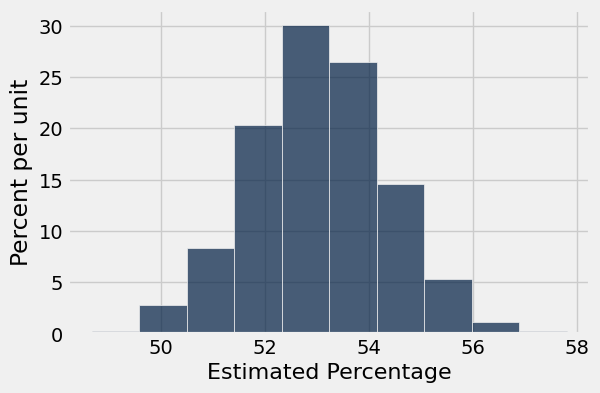

In [6]:
resampled_percentages = percentages_in_resamples()
Table().with_column('Estimated Percentage', resampled_percentages).hist("Estimated Percentage")

**Question 1.3. (2 pts)** Using the array `resampled_percentages`, find the values at the two edges of the middle 95% of the bootstrapped percentage estimates. (Compute the lower and upper ends of the interval, named `imm_lower_bound` and `imm_upper_bound`, respectively.)

*Hint:* If you are stuck on this question, try looking over [Chapter 13](https://inferentialthinking.com/chapters/13/Estimation.html) of the textbook.

In [7]:
imm_lower_bound = percentile(2.5, resampled_percentages)
imm_upper_bound = percentile(97.5, resampled_percentages)
print(f"Bootstrapped 95% confidence interval for the percentage of Imm Thai voters in the population: [{imm_lower_bound:.2f}, {imm_upper_bound:.2f}]")

Bootstrapped 95% confidence interval for the percentage of Imm Thai voters in the population: [50.47, 55.60]


In [8]:
grader.check("q1_3")

q1_3 results: All test cases passed!

**Question 1.4. (3 pts)** The survey results seem to indicate that Imm Thai is beating all the other Thai restaurants combined among voters. We would like to use confidence intervals to determine a range of likely values for Imm Thai's true lead over all the other restaurants combined. The calculation for Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined is:

$$\text{Imm Thai's % of the vote} - (\text{100 %} - \text{Imm Thai's % of Vote})$$

For example, if Imm Thai's % of vote is 54, then its lead over all others combined is: $$54 - (100-54) = 54 - 46 = 8$$

Define the function `one_resampled_difference` that returns the value of Imm Thai's percentage lead over Lucky House, Thai Temple, and Thai Basil combined from one bootstrap sample of `tbl`. 

*Hint 1:* Imm Thai's lead can be negative. **Be sure to use percentages, not proportions, for this question!**

In [9]:
def one_resampled_difference(tbl):
    bootstrap = tbl.sample()
    imm_percentage = one_resampled_percentage(bootstrap)
    return imm_percentage - (100 - imm_percentage)

In [10]:
grader.check("q1_4")

q1_4 results: All test cases passed!

In [11]:
# check
one_resampled_difference(votes)

4.266666666666666

**Question 1.5. (3 pts)** Write a function called `leads_in_resamples` that finds 2500 bootstrapped estimates (the result of calling `one_resampled_difference`) of Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined. Plot a histogram of the resulting samples. 

*Hint:* If you see an error involving “NoneType”, consider what components a function needs to have. 

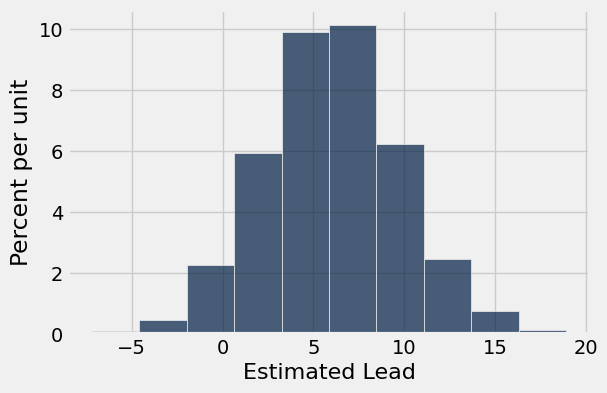

In [12]:
def leads_in_resamples():
    samp = make_array()
    for i in np.arange(2500):
        samp = np.append(samp, one_resampled_difference(votes))
    return samp

sampled_leads = leads_in_resamples()
Table().with_column('Estimated Lead', sampled_leads).hist("Estimated Lead")

**Question 1.6. (2 pts)** Use the simulated data in `sampled_leads` from Question 1.5 to compute an approximate 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined. 

In [13]:
diff_lower_bound = percentile(2.5, sampled_leads)
diff_upper_bound = percentile(97.5, sampled_leads)
print("Bootstrapped 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined: [{:f}%, {:f}%]".format(diff_lower_bound, diff_upper_bound))

Bootstrapped 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined: [-1.200000%, 13.466667%]


In [14]:
grader.check("q1_6")

q1_6 results: All test cases passed!

## 2. Interpreting Confidence Intervals 

The staff computed the following 95% confidence interval for the percentage of Imm Thai voters: 

$$[50.53, 55.53]$$

(Your answer may have been a bit different due to randomness; that doesn't mean it was wrong!)

**Question 2.1. (5 pts)** The staff also created 70%, 90%, and 99% confidence intervals from the same sample, but we forgot to label which confidence interval represented which percentages! First, match each confidence level (70%, 90%, 99%) with its corresponding interval in the cell below (e.g. __ % CI: [52.1, 54] $\rightarrow$ replace the blank with one of the three confidence levels). **Then**, explain your thought process and how you came up with your answers. 

The intervals are below:

* [50.03, 55.94]
* [52.1, 54]
* [50.97, 54.99]


70% CI: [52.1, 54]

90% CI: [50.97, 54.99]

99% CI: [50.03, 55.94]

I assigned these values to the given confidence intervals because as the interval gets smaller the confidence level does as well. So, a smaller confidence interval will have a lower confidence level and a larger confidence interval will have a higher confidence level.

**Question 2.2. (2 pts)** Suppose we produced 6,000 new samples (each one a uniform random sample of 1,500 voters/residents) from the population and created a 95% confidence interval from each one. Roughly how many of those 6,000 intervals do you expect will actually contain the true percentage of the population? 

Assign your answer to `true_percentage_intervals`.

In [15]:
true_percentage_intervals = (6000)*(.95)

In [16]:
grader.check("q2_2")

q2_2 results: All test cases passed!

Recall the second bootstrap confidence interval you created, which estimated Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined. Among voters in the sample, Imm Thai's lead was 6%. In our computation the 95% confidence interval for the true lead (in the population of all voters) was:

$$[1.2, 11.2]$$

Suppose we are interested in testing a simple yes-or-no question:

> "Is the percentage of votes for Imm Thai equal to the percentage of votes for Lucky House, Thai Temple, and Thai Basil combined?"

Our null hypothesis is that the percentages are equal, or equivalently, that Imm Thai's lead is exactly 0. Our alternative hypothesis is that Imm Thai's lead is not equal to 0.  In the questions below, don't compute any confidence interval yourself - use only our computed 95% confidence interval.

**Question 2.3. (2 pts)** Say we use a 5% p-value cutoff. Do we reject the null, fail to reject the null, or are we unable to tell using the staff's confidence interval?

Assign `restaurants_equal` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our computed confidence interval

*Hint:* Consider the relationship between the p-value cutoff and confidence. If you're confused, take a look at [Chap 13.4](https://inferentialthinking.com/chapters/13/4/Using_Confidence_Intervals.html) of the textbook.

In [17]:
restaurants_equal = 1

In [18]:
grader.check("q2_3")

q2_3 results: All test cases passed!

**Question 2.4. (2 pta)** What if, instead, we use a P-value cutoff of 1%? Do we reject the null, fail to reject the null, or are we unable to tell using our staff confidence interval? 

Assign `cutoff_one_percent` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our computed confidence interval

In [1]:
cutoff_one_percent = 3

**Question 2.5. (2 pts)** What if we use a p-value cutoff of 10%? Do we reject, fail to reject, or are we unable to tell using our confidence interval? 

Assign `cutoff_ten_percent` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our computed confidence interval


In [21]:
cutoff_ten_percent = 1

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [22]:
grader.check_all()

q1_1 results: All test cases passed!

q1_3 results: All test cases passed!

q1_4 results: All test cases passed!

q1_6 results: All test cases passed!

q2_2 results: All test cases passed!

q2_3 results: All test cases passed!

**You've completed Homework 9!**

Please save your notebook, download a pdf version of the notebook, and submit it to Gradescope.